In [1]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned_new_v3.xlsx", sheet_name="Sheet1")
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5494 non-null   object 
 1   MW                 5494 non-null   float64
 2   LogP               5494 non-null   float64
 3   NumHDonors         5494 non-null   int64  
 4   TPSA               5494 non-null   float64
 5   NumRotatableBonds  5494 non-null   int64  
 6   bioactivity        5494 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 300.6+ KB


In [4]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [5]:
df['bioactivity'].value_counts()

bioactivity
1    4326
0    1168
Name: count, dtype: int64

In [6]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# CONFIG (Fixed)
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 512
BATCH_SIZE = 32
ECFP_BITS = 1024
ECFP_RADIUS = 2
AUGMENT_TRAIN = True


train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

scaler=StandardScaler().fit(train_df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds']])

# -------------------------------
# SMILES Augmentation
# -------------------------------
def random_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return smiles
    return Chem.MolToSmiles(mol, doRandom=True, canonical=False)

# -------------------------------
# ECFP Generator
# -------------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_BITS)
def get_ecfp(smiles, radius=ECFP_RADIUS, n_bits=ECFP_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------
# Dataset
# -------------------------------

tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)

class BioActivityDataset(Dataset):
    def __init__(self, df, tokenizer, scaler=None, ecfp_cache=None, augment=False):
        self.smiles = df['canonical_smiles'].values.tolist()
        self.desc   = df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds']].values.astype(np.float32)
        self.labels = df['bioactivity'].values.astype(np.float32)
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
        self.augment = augment
        self.max_len = MAX_LEN

        
        if scaler is None:
            self.scaler = StandardScaler().fit(self.desc)
        else:
            self.scaler = scaler
        self.desc = self.scaler.transform(self.desc)
        
        print("Computing ECFP...")
        self.ecfp = np.stack([get_ecfp(s) for s in self.smiles])
        

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx): 
        item = {k: v[idx] for k, v in self.encodings.items()}

        item['ecfp']=torch.tensor(self.ecfp[idx])
        item['descriptors']=torch.tensor(self.desc[idx])
        item['labels']=torch.tensor(self.labels[idx])

        return item

# -------------------------------
# Collate Function
# -------------------------------
def collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'descriptors': torch.stack([b['descriptors'] for b in batch]),
        'ecfp': torch.stack([b['ecfp'] for b in batch]),
        'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.float)
    }



In [7]:
train_dataset = BioActivityDataset(train_df, tokenizer, scaler=scaler)
val_dataset = BioActivityDataset(val_df, tokenizer, scaler=scaler)
test_dataset = BioActivityDataset(test_df, tokenizer, scaler=scaler)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Computing ECFP...
Computing ECFP...
Computing ECFP...


In [8]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    3028
 0     817
 Name: count, dtype: int64,
 bioactivity
 1    645
 0    179
 Name: count, dtype: int64,
 bioactivity
 1    653
 0    172
 Name: count, dtype: int64)

#### ECFP + BERT embedding based model

In [7]:
# -------------------------------
# Model
# -------------------------------
class FineTunedBERTaECFP(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, n_descriptors=5, unfreeze_layers=12, num_heads=8, 
                 dropout=0.3, hidden_dim=768, num_classifier_layers=4, 
                 fusion_type='gated'):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # Unfreeze last N layers
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Project ECFP and descriptors to 768
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.desc_proj = nn.Sequential(
            nn.Linear(n_descriptors, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Attention
        self.attn = nn.MultiheadAttention(768, num_heads=num_heads, batch_first=True, dropout=dropout*0.5)
        self.attn_norm = nn.LayerNorm(768)

        self.fusion_type = fusion_type
        if fusion_type == 'gated':
            self.gate = nn.Sequential(
                nn.Linear(768 * 3, 768),
                nn.Sigmoid()
            )
            self.fusion_proj = nn.Linear(768 * 3, 768)
        elif fusion_type == 'bilinear':
            self.bilinear = nn.Bilinear(768, 768, 768)

        # Classifier
        classifier_layers = []
        in_dim = 768 * 3 if fusion_type == 'concat' else 768
        
        for i in range(num_classifier_layers):
            out_dim = hidden_dim // (2 ** i)
            classifier_layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout if i < num_classifier_layers - 1 else dropout * 0.5)
            ])
            in_dim = out_dim
        
        classifier_layers.append(nn.Linear(in_dim, 1))
        self.classifier = nn.Sequential(*classifier_layers)


    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # SMILES
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_ = out.last_hidden_state[:,0]
        mean_pool = out.last_hidden_state.mean(dim=1)  # [B,768]
        max_pool = out.last_hidden_state.max(dim=1)[0]
        smiles = (cls_ + mean_pool + max_pool) / 3

        # ECFP + Desc
        ecfp_emb = self.ecfp_proj(ecfp)             # [B,768]
        desc_emb = self.desc_proj(descriptors)      # [B,768]

        # Attention
        q = torch.stack([ecfp_emb, desc_emb], dim=1)  # [B,2,768]
        kv = smiles.unsqueeze(1)                       # [B,1,768]
        attn_out, attn_weights = self.attn(q, kv, kv)             # [B,2,768]

        ecfp_attn = self.attn_norm(attn_out[:,0] + ecfp_emb)    # [B,768]
        desc_attn = self.attn_norm(attn_out[:,1] + desc_emb)   # [B,768]

        # Fuse
        if self.fusion_type == 'concat':
            fused = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)
        elif self.fusion_type == 'gated':
            concat = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)
            gate = self.gate(concat)
            fused = gate * self.fusion_proj(concat)
        else:  # bilinear
            fused = self.bilinear(smiles, ecfp_attn + desc_attn)
        
        return self.classifier(fused).squeeze(-1)

model = FineTunedBERTaECFP(unfreeze_layers=12, num_heads=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedBERTaECFP(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (d

#### V2 Architecture: Cross-Modal Transformer + MACCS Keys + Expanded Descriptors

In [10]:

# ─────────────────────────────────────────────────────────────────────────────
# V2: Extended Features + Dataset + FocalLoss + Model
#
# Improvements over v1:
#   1. Attention pooling over SMILES token sequence (learned weights)
#   2. MACCS keys (167-bit) as a 4th modality
#   3. 6 Lipinski Rule-of-Five descriptors (MW, LogP, HBD, HBA, TPSA, RotBonds)
#   4. Cross-modal Transformer (Pre-LN): all 4 modalities attend to each other
#   5. FocalLoss with label smoothing — targets hard boundary examples
#   6. On-the-fly SMILES augmentation (random non-canonical strings)
# ─────────────────────────────────────────────────────────────────────────────
import torch.nn.functional as F
from rdkit.Chem import MACCSkeys

MACCS_BITS        = 167
N_DESCRIPTORS_EXT = 6   # Lipinski RO5: MW, LogP, HBD, HBA, TPSA, RotBonds

def compute_extended_descriptors(smiles):
    """Lipinski Rule-of-Five + TPSA + RotBonds (6 descriptors)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(N_DESCRIPTORS_EXT, dtype=np.float32)
    try:
        return np.array([
            Descriptors.MolWt(mol),              # MW      ≤ 500
            Descriptors.MolLogP(mol),            # LogP    ≤ 5
            Descriptors.NumHDonors(mol),         # HBD     ≤ 5
            Descriptors.NumHAcceptors(mol),      # HBA     ≤ 10
            Descriptors.TPSA(mol),               # TPSA    < 140
            Descriptors.NumRotatableBonds(mol),  # RotBond ≤ 10
        ], dtype=np.float32)
    except Exception:
        return np.zeros(N_DESCRIPTORS_EXT, dtype=np.float32)

def get_maccs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(MACCS_BITS, dtype=np.float32)
    fp  = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((MACCS_BITS,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# ── Dataset ───────────────────────────────────────────────────────────────────
class BioActivityDataset_v2(Dataset):
    def __init__(self, df, tokenizer, scaler=None, augment=False):
        self.tokenizer = tokenizer          # kept for on-the-fly augmentation
        self.smiles    = df['canonical_smiles'].values.tolist()
        self.labels    = df['bioactivity'].values.astype(np.float32)
        self.augment   = augment
        # padding='max_length' ensures consistency with on-the-fly tokenised augmentations
        self.encodings = tokenizer(
            self.smiles, truncation=True, padding='max_length',
            max_length=512, return_tensors='pt'
        )
        raw_desc = np.stack([compute_extended_descriptors(s) for s in self.smiles])
        if scaler is None:
            self.scaler = StandardScaler().fit(raw_desc)
        else:
            self.scaler = scaler
        self.desc  = self.scaler.transform(raw_desc).astype(np.float32)
        print("Computing ECFP...")
        self.ecfp  = np.stack([get_ecfp(s)  for s in self.smiles])
        print("Computing MACCS...")
        self.maccs = np.stack([get_maccs(s) for s in self.smiles])

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        # 50% chance: re-tokenise a random non-canonical SMILES string
        if self.augment and random.random() < 0.5:
            aug_smi = random_smiles(self.smiles[idx])
            enc     = self.tokenizer(
                [aug_smi], truncation=True, padding='max_length',
                max_length=512, return_tensors='pt'
            )
            item = {k: v[0] for k, v in enc.items()}
        else:
            item = {k: v[idx] for k, v in self.encodings.items()}
        item['ecfp']        = torch.tensor(self.ecfp[idx])
        item['maccs']       = torch.tensor(self.maccs[idx])
        item['descriptors'] = torch.tensor(self.desc[idx])
        item['labels']      = torch.tensor(self.labels[idx])
        return item

def collate_fn_v2(batch):
    return {
        'input_ids':      torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'ecfp':           torch.stack([b['ecfp']           for b in batch]),
        'maccs':          torch.stack([b['maccs']          for b in batch]),
        'descriptors':    torch.stack([b['descriptors']    for b in batch]),
        'labels':         torch.tensor([b['labels']        for b in batch], dtype=torch.float),
    }


# ── Focal Loss with label smoothing ───────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Binary Focal Loss with label smoothing.

    Intuition
    ---------
    Standard BCE penalises every error equally. When the model is very
    confident and correct (p ≈ 1 for a positive), the gradient is tiny
    anyway — but it still wastes capacity. Focal loss multiplies by
    (1-p)^gamma, so easy well-classified examples contribute almost
    nothing to training and the model focuses its capacity on the hard
    boundary cases that cause the accuracy plateau.

      alpha   : upweight for positives  (≈ class_neg / class_pos)
      gamma   : focusing exponent       (0 = plain BCE, 2 = standard focal)
      smoothing: label smoothing ε      (prevents overconfident logits)
    """
    def __init__(self, alpha=0.75, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        y    = targets * (1 - self.smoothing) + 0.5 * self.smoothing   # smooth labels
        bce  = F.binary_cross_entropy_with_logits(logits, y, reduction='none')
        pt   = torch.exp(-bce)                                          # p_correct
        a_t  = self.alpha * targets + (1 - self.alpha) * (1 - targets) # per-sample alpha
        loss = a_t * (1 - pt) ** self.gamma * bce
        return loss.mean()


# ── V2 Model ──────────────────────────────────────────────────────────────────
class FineTunedBERTaECFP_v2(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, maccs_bits=MACCS_BITS,
                 n_descriptors=N_DESCRIPTORS_EXT,
                 unfreeze_layers=9, num_heads=8, dropout=0.2,
                 hidden_dim=512, num_classifier_layers=4, n_cross_layers=2):
        super().__init__()
        D = 768

        self.bert = AutoModel.from_pretrained(
            "ibm/MoLFormer-XL-both-10pct", trust_remote_code=True
        )
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.token_attn = nn.Linear(D, 1)

        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(512, D),         nn.LayerNorm(D),   nn.GELU(), nn.Dropout(dropout),
        )
        self.maccs_proj = nn.Sequential(
            nn.Linear(maccs_bits, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(256, D),          nn.LayerNorm(D),   nn.GELU(), nn.Dropout(dropout),
        )
        self.desc_proj = nn.Sequential(
            nn.Linear(n_descriptors, 64), nn.GELU(), nn.LayerNorm(64), nn.Dropout(dropout * 0.5),
            nn.Linear(64,             D), nn.GELU(), nn.LayerNorm(D),  nn.Dropout(dropout),
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=num_heads, dim_feedforward=D * 4,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.cross_modal = nn.TransformerEncoder(enc_layer, num_layers=n_cross_layers)

        self.gate        = nn.Sequential(nn.Linear(D * 4, D), nn.Sigmoid())
        self.fusion_proj = nn.Linear(D * 4, D)

        layers, in_dim = [], D
        for i in range(num_classifier_layers):
            out_dim = hidden_dim // (2 ** i)
            layers.extend([
                nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(),
                nn.Dropout(dropout if i < num_classifier_layers - 1 else dropout * 0.5),
            ])
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.classifier = nn.Sequential(*layers)

    def forward(self, input_ids, attention_mask, ecfp, maccs, descriptors):
        hidden    = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        scores    = self.token_attn(hidden).squeeze(-1)
        scores    = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        weights   = torch.softmax(scores, dim=-1).unsqueeze(-1)
        attn_pool = (hidden * weights).sum(dim=1)
        smiles    = (hidden[:, 0] + hidden.mean(dim=1) + attn_pool) / 3

        ecfp_emb  = self.ecfp_proj(ecfp)
        maccs_emb = self.maccs_proj(maccs)
        desc_emb  = self.desc_proj(descriptors)

        tokens = torch.stack([smiles, ecfp_emb, maccs_emb, desc_emb], dim=1)
        tokens = self.cross_modal(tokens)

        flat  = tokens.reshape(tokens.size(0), -1)
        fused = self.gate(flat) * self.fusion_proj(flat)
        return self.classifier(fused).squeeze(-1)


#### V3 Architecture

In [12]:

# ─────────────────────────────────────────────────────────────────────────────
# V3 Architecture — Improvements over V2:
#
#   1. Multi-layer weighted BERT pooling (last 4 hidden states)
#   2. Deeper cross-modal Transformer (3 layers, Pre-LN)
#   3. FIXED: Modality type embeddings — 4 learnable vectors tell the
#      cross-modal Transformer which token is SMILES / ECFP / MACCS / DESC.
#      Without these, attention cannot distinguish modalities by type.
#   4. FIXED: modal_type_embed uses xavier_uniform_ init (not Normal(0,1))
#      so type embeddings start at the same scale as projected features.
#   5. FIXED: Gate has LayerNorm before Sigmoid to prevent saturation.
#   6. FIXED: Projections use GELU → LayerNorm (not LayerNorm → GELU) so
#      each modality token enters the cross-modal Transformer with unit
#      variance, making type-embedding addition scale-consistent.
#   7. FIXED: mean_pool excludes padding tokens (masked mean).
#   8. FIXED: Per-modality gate (D→D per token) replaces global gate (4D→D).
#   9. FIXED: freeze_bottom_n layers frozen in __init__ — class is self-
#      protecting against catastrophic forgetting if LLRD is not used.
# ─────────────────────────────────────────────────────────────────────────────
import torch.nn.functional as F

class FineTunedBERTaECFP_v3(nn.Module):
    def __init__(
        self,
        ecfp_bits             = ECFP_BITS,
        maccs_bits            = MACCS_BITS,
        n_descriptors         = N_DESCRIPTORS_EXT,
        num_heads             = 8,
        dropout               = 0.2,
        hidden_dim            = 512,
        num_classifier_layers = 4,
        n_cross_layers        = 3,
        n_pool_layers         = 4,
        freeze_bottom_n       = 4,
    ):
        super().__init__()
        D = 768

        self.bert = AutoModel.from_pretrained(
            "ibm/MoLFormer-XL-both-10pct", trust_remote_code=True
        )

        # Freeze bottom freeze_bottom_n encoder layers to prevent catastrophic
        # forgetting of chemistry pretraining. Top layers remain trainable via
        # LLRD. Default=4 matches the training-cell freeze setting.
        for layer in self.bert.encoder.layer[:freeze_bottom_n]:
            for p in layer.parameters():
                p.requires_grad = False

        self.n_pool_layers = n_pool_layers
        self.layer_weights = nn.Parameter(torch.zeros(n_pool_layers))
        self.token_attn    = nn.Linear(D, 1)

        # ── Modality type embeddings ──────────────────────────────────────────
        # 4 learnable vectors: idx 0=SMILES, 1=ECFP, 2=MACCS, 3=DESC.
        # xavier_uniform_ keeps initial scale ≈ 0.05 — same order of magnitude
        # as the LayerNorm-normalised projection outputs (unit variance).
        self.modal_type_embed = nn.Embedding(4, D)
        nn.init.xavier_uniform_(self.modal_type_embed.weight)

        # ── Modality projections (GELU → LayerNorm at each stage) ─────────────
        # Ending each stage with LayerNorm ensures the token entering the
        # cross-modal Transformer has unit variance, so type-embedding addition
        # is scale-consistent across all four modalities.
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits,  512), nn.GELU(), nn.LayerNorm(512), nn.Dropout(dropout * 0.5),
            nn.Linear(512,          D), nn.GELU(), nn.LayerNorm(D),   nn.Dropout(dropout),
        )
        self.maccs_proj = nn.Sequential(
            nn.Linear(maccs_bits, 256), nn.GELU(), nn.LayerNorm(256), nn.Dropout(dropout * 0.5),
            nn.Linear(256,          D), nn.GELU(), nn.LayerNorm(D),   nn.Dropout(dropout),
        )
        self.desc_proj = nn.Sequential(
            nn.Linear(n_descriptors, 64), nn.GELU(), nn.LayerNorm(64), nn.Dropout(dropout * 0.5),
            nn.Linear(64,              D), nn.GELU(), nn.LayerNorm(D),  nn.Dropout(dropout),
        )

        # ── Cross-modal Transformer (Pre-LN) ──────────────────────────────────
        enc_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=num_heads, dim_feedforward=D * 4,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.cross_modal = nn.TransformerEncoder(enc_layer, num_layers=n_cross_layers)

        # ── Gated fusion (per-modality) ───────────────────────────────────────
        # Gate applied to each of the 4 tokens independently [B,4,D] → [B,4,D].
        # Each modality+dimension gets its own learned gate value — not a single
        # global gate over the concatenation. 590K params vs 2.36M previously.
        self.gate        = nn.Sequential(nn.Linear(D, D), nn.LayerNorm(D), nn.Sigmoid())
        self.fusion_proj = nn.Linear(D * 4, D)

        # ── Classifier MLP ────────────────────────────────────────────────────
        layers, in_dim = [], D
        for i in range(num_classifier_layers):
            out_dim = hidden_dim // (2 ** i)
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU(),
                nn.Dropout(dropout if i < num_classifier_layers - 1 else dropout * 0.5),
            ])
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.classifier = nn.Sequential(*layers)

    def forward(self, input_ids, attention_mask, ecfp, maccs, descriptors):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )

        # ── Weighted aggregation of last n BERT hidden states ─────────────────
        # outputs.hidden_states: 13 tensors — [embedding, layer1, ..., layer12].
        # Slice [-n_pool_layers:] selects the top encoder layers only, never
        # the embedding (layer 0). With n_pool_layers=4: layers 9, 10, 11, 12.
        # weights[0] → layer 9 (deepest selected), weights[3] → layer 12 (last).
        all_hidden = outputs.hidden_states           # 13 tensors
        selected   = all_hidden[-self.n_pool_layers:]    # top n encoder layers
        weights    = torch.softmax(self.layer_weights, dim=0)
        hidden     = sum(w * h for w, h in zip(weights, selected))

        # ── Multi-strategy SMILES pooling ─────────────────────────────────────
        cls_pool      = hidden[:, 0]
        mask_expanded = attention_mask.unsqueeze(-1).float()   # [B, seq_len, 1]
        mean_pool     = (hidden * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)
        scores        = self.token_attn(hidden).squeeze(-1)
        scores        = scores.masked_fill(~attention_mask.bool(), float('-inf'))
        attn_pool     = (hidden * torch.softmax(scores, dim=-1).unsqueeze(-1)).sum(dim=1)
        smiles        = (cls_pool + mean_pool + attn_pool) / 3

        # ── Modality projections ──────────────────────────────────────────────
        ecfp_emb  = self.ecfp_proj(ecfp)
        maccs_emb = self.maccs_proj(maccs)
        desc_emb  = self.desc_proj(descriptors)

        # ── Add modality type embeddings before cross-modal attention ─────────
        B         = smiles.size(0)
        modal_ids = torch.arange(4, device=smiles.device)           # [0,1,2,3]
        type_embs = self.modal_type_embed(modal_ids)                # [4, D]
        tokens    = torch.stack([smiles, ecfp_emb, maccs_emb, desc_emb], dim=1)  # [B, 4, D]
        tokens    = tokens + type_embs.unsqueeze(0)                 # broadcast [1, 4, D]

        # ── Cross-modal Transformer + per-modality gated fusion ───────────────
        tokens = self.cross_modal(tokens)                           # [B, 4, D]
        gates  = self.gate(tokens)                                  # [B, 4, D] — per-modality gate
        flat   = (gates * tokens).reshape(B, -1)                    # [B, 4D]   — gated & flattened
        fused  = self.fusion_proj(flat)                             # [B, D]

        return self.classifier(fused).squeeze(-1)

print("FineTunedBERTaECFP_v3 defined — all 9 fixes applied.")


FineTunedBERTaECFP_v3 defined — all 9 fixes applied.


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# V3 Hyperparameter Optimization with Optuna
#
# Key differences from V2 HPO:
#   1. Uses FineTunedBERTaECFP_v3 (modality embeddings, multi-layer pooling)
#   2. WeightedRandomSampler in every trial — class balance at data level
#   3. LLRD optimizer (not plain AdamW) — same optimizer as final V3 training
#   4. focal_alpha=0.50 fixed — sampler handles class balance; alpha unnecessary
#   5. focal_gamma and n_pool_layers fixed — low-impact, not worth search cost
#   6. Freeze bottom 4 BERT layers — stable baseline for all trials
#   7. LR search range raised: [1e-6, 2e-5] — LLRD reduces lower layers, so
#      base_lr can be higher than V2's plain-AdamW range [5e-7, 1e-5]
#   8. n_cross_layers searched: [2, 3] — V3 added cross-layer depth
#   9. Metric: ROC-AUC (primary discrimination measure, threshold-independent)
# ─────────────────────────────────────────────────────────────────────────────
from optuna.pruners import HyperbandPruner
from optuna.samplers import TPESampler
from torch.utils.data import WeightedRandomSampler
import math, json

USE_AMP    = DEVICE.type == 'cuda'
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

# ── Pre-compute datasets ONCE (50% subsample for speed) ──────────────────────
print("Pre-computing V3 HPO datasets (once for all trials)...")
_hpo_train_df_v3 = train_df.sample(frac=0.5, random_state=42)
_tr_ds_hpo_v3    = BioActivityDataset_v2(_hpo_train_df_v3, tokenizer, augment=True)
_vl_ds_hpo_v3    = BioActivityDataset_v2(val_df, tokenizer, scaler=_tr_ds_hpo_v3.scaler)

# Pre-compute WeightedRandomSampler weights for the HPO subsample
_hpo_labels      = _tr_ds_hpo_v3.labels.astype(int)
_hpo_class_count = np.bincount(_hpo_labels)
_hpo_sample_wt   = (1.0 / _hpo_class_count)[_hpo_labels]

print(f"HPO train: {len(_hpo_train_df_v3)}  Val: {len(val_df)}")
print(f"AMP={'ON' if USE_AMP else 'OFF'} ({_AMP_DTYPE}). Ready.\n")


def build_llrd_optimizer_hpo(model, base_lr, weight_decay, decay_factor=0.95):
    """Minimal LLRD builder reused inside each trial."""
    no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    groups   = []

    # Task head
    head_p = [(n, p) for n, p in model.named_parameters()
               if not n.startswith('bert.') and p.requires_grad]
    groups += [
        {'params': [p for n, p in head_p if not any(nd in n for nd in no_decay)],
         'lr': base_lr, 'weight_decay': weight_decay},
        {'params': [p for n, p in head_p if any(nd in n for nd in no_decay)],
         'lr': base_lr, 'weight_decay': 0.0},
    ]

    # BERT encoder — top layer gets base_lr, decay downward; skip frozen
    for depth, layer in enumerate(reversed(list(model.bert.encoder.layer))):
        lr_l = base_lr * (decay_factor ** depth)
        lp   = [(n, p) for n, p in layer.named_parameters() if p.requires_grad]
        if not lp:
            continue
        groups += [
            {'params': [p for n, p in lp if not any(nd in n for nd in no_decay)],
             'lr': lr_l, 'weight_decay': weight_decay},
            {'params': [p for n, p in lp if any(nd in n for nd in no_decay)],
             'lr': lr_l, 'weight_decay': 0.0},
        ]

    # Embeddings
    if hasattr(model.bert, 'embeddings'):
        emb_lr = base_lr * (0.95 ** len(model.bert.encoder.layer))
        ep     = [(n, p) for n, p in model.bert.embeddings.named_parameters()
                  if p.requires_grad]
        if ep:
            groups += [
                {'params': [p for n, p in ep if not any(nd in n for nd in no_decay)],
                 'lr': emb_lr, 'weight_decay': weight_decay},
                {'params': [p for n, p in ep if any(nd in n for nd in no_decay)],
                 'lr': emb_lr, 'weight_decay': 0.0},
            ]

    return optim.AdamW(groups)


def objective_v3(trial):
    # ── Search space ──────────────────────────────────────────────────────────
    num_heads             = trial.suggest_categorical('num_heads',             [4, 8])
    hidden_dim            = trial.suggest_categorical('hidden_dim',            [256, 512])
    dropout               = trial.suggest_float('dropout',                     0.1, 0.4, step=0.1)
    num_classifier_layers = trial.suggest_int('num_classifier_layers',         2, 4, step=1)
    n_cross_layers        = trial.suggest_int('n_cross_layers',                2, 3)
    batch_size            = trial.suggest_categorical('batch_size',            [32, 64])
    learning_rate         = trial.suggest_float('learning_rate',               1e-6, 2e-5, log=True)
    weight_decay          = trial.suggest_float('weight_decay',                1e-5, 1e-3, log=True)
    # Fixed: focal_alpha=0.50 (sampler handles class balance), n_pool_layers=4, freeze_bottom=4

    try:
        model = FineTunedBERTaECFP_v3(
            num_heads             = num_heads,
            dropout               = dropout,
            hidden_dim            = hidden_dim,
            num_classifier_layers = num_classifier_layers,
            n_cross_layers        = n_cross_layers,
            n_pool_layers         = 4,
            freeze_bottom_n       = 4,   # handled in __init__
        ).to(DEVICE)
    except Exception:
        raise optuna.exceptions.TrialPruned()

    # WeightedRandomSampler — balanced batches
    _sampler_hpo = WeightedRandomSampler(
        weights=torch.tensor(_hpo_sample_wt, dtype=torch.float),
        num_samples=len(_hpo_sample_wt), replacement=True,
    )
    tr_ldr = DataLoader(_tr_ds_hpo_v3, batch_size=batch_size,     sampler=_sampler_hpo,
                        collate_fn=collate_fn_v2, num_workers=0)
    vl_ldr = DataLoader(_vl_ds_hpo_v3, batch_size=batch_size * 2, shuffle=False,
                        collate_fn=collate_fn_v2, num_workers=0)

    criterion  = FocalLoss(alpha=0.50, gamma=2.0, smoothing=0.05)
    optimizer  = build_llrd_optimizer_hpo(model, learning_rate, weight_decay)
    MAX_EPOCHS = 25  # early stopping + pruning should prevent full runs for most trials
    total_steps  = (len(tr_ldr) // 1) * MAX_EPOCHS   # no grad accum in HPO
    warmup_steps = max(1, int(0.10 * total_steps))

    def _wc(step):
        if step < warmup_steps:
            return float(step) / float(warmup_steps)
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_wc)
    amp_scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and _AMP_DTYPE == torch.float16))

    best_auc, patience, p_ctr = 0.0, 5, 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        for batch in tr_ldr:
            try:
                optimizer.zero_grad()
                with torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
                    logits = model(
                        input_ids      = batch['input_ids'].to(DEVICE),
                        attention_mask = batch['attention_mask'].to(DEVICE),
                        ecfp           = batch['ecfp'].to(DEVICE),
                        maccs          = batch['maccs'].to(DEVICE),
                        descriptors    = batch['descriptors'].to(DEVICE),
                    )
                    loss = criterion(logits, batch['labels'].float().to(DEVICE))
                    if not torch.isfinite(loss):
                        optimizer.zero_grad(); continue
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()
                scheduler.step()          # step-based: call after every optimizer update
                optimizer.zero_grad()
            except RuntimeError as e:
                if 'out of memory' in str(e):
                    torch.cuda.empty_cache(); continue
                raise

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_probs_h, val_lbls_h = [], []
        with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
            for batch in vl_ldr:
                try:
                    logits = model(
                        input_ids      = batch['input_ids'].to(DEVICE),
                        attention_mask = batch['attention_mask'].to(DEVICE),
                        ecfp           = batch['ecfp'].to(DEVICE),
                        maccs          = batch['maccs'].to(DEVICE),
                        descriptors    = batch['descriptors'].to(DEVICE),
                    )
                    val_probs_h.extend(torch.sigmoid(logits.float()).cpu().numpy())
                    val_lbls_h.extend(batch['labels'].cpu().numpy())
                except RuntimeError:
                    torch.cuda.empty_cache(); continue

        if not val_probs_h:
            raise optuna.exceptions.TrialPruned()

        val_probs_arr = np.array(val_probs_h)
        if np.isnan(val_probs_arr).mean() > 0.05:
            raise optuna.exceptions.TrialPruned()

        val_auc = roc_auc_score(val_lbls_h, val_probs_arr)
        trial.report(val_auc, epoch)
        if trial.should_prune():
            break

        if val_auc > best_auc + 1e-5:
            best_auc = val_auc; p_ctr = 0
        else:
            p_ctr += 1
            if p_ctr >= patience:
                break

    del model; torch.cuda.empty_cache()
    return best_auc


def run_v3_optimization():
    print("=" * 70)
    print("  V3 HYPERPARAMETER OPTIMIZATION")
    print("=" * 70)
    print(f"  Device: {DEVICE}  |  AMP dtype: {_AMP_DTYPE}")
    print(f"  HPO Train: {len(_hpo_train_df_v3)}  Val: {len(val_df)}")
    print(f"  Trials: 40  |  Max epochs/trial: 25  |  LLRD + WeightedSampler")
    print("=" * 70)

    study_v3 = optuna.create_study(
        study_name='bioactivity_v3',
        direction='maximize',
        sampler=TPESampler(seed=42),
        pruner=HyperbandPruner(min_resource=5, max_resource=25, reduction_factor=3),
    )
    study_v3.optimize(
        objective_v3,
        n_trials=40,
        timeout=3600 * 4,
        show_progress_bar=True,
    )

    print(f"\nBest Trial  : #{study_v3.best_trial.number}")
    print(f"Best AUROC  : {study_v3.best_value:.4f}")
    print("\nBest V3 Hyperparameters:")
    for k, v in best_params_v3.items():
        print(f"  {k:<25}: {v}")

    with open('optuna_results_v3__.json', 'w') as f:
        json.dump({'best_value': study_v3.best_value,
                   'best_params': best_params_v3,
                   'n_trials': len(study_v3.trials)}, f, indent=4)
    print("\nResults saved to optuna_results_v3__.json")
    return study_v3


study_v3 = run_v3_optimization()


Pre-computing V3 HPO datasets (once for all trials)...
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...


[I 2026-05-19 22:03:23,605] A new study created in memory with name: bioactivity_v3


HPO train: 1922  Val: 824
AMP=ON (torch.bfloat16). Ready.

  V3 HYPERPARAMETER OPTIMIZATION
  Device: cuda  |  AMP dtype: torch.bfloat16
  HPO Train: 1922  Val: 824
  Trials: 40  |  Max epochs/trial: 25  |  LLRD + WeightedSampler


Best trial: 0. Best value: 0.935308:   2%|▎         | 1/40 [05:07<3:19:39, 307.16s/it, 307.16/14400 seconds]

[I 2026-05-19 22:08:30,761] Trial 0 finished with value: 0.9353081287081546 and parameters: {'num_heads': 8, 'hidden_dim': 256, 'dropout': 0.1, 'num_classifier_layers': 2, 'n_cross_layers': 2, 'batch_size': 32, 'learning_rate': 8.341106432362091e-06, 'weight_decay': 1.0994335574766187e-05}. Best is trial 0 with value: 0.9353081287081546.


...

[I 2026-05-20 00:00:54,630] Trial 37 finished with value: 0.9293837425836907 and parameters: {'num_heads': 4, 'hidden_dim': 256, 'dropout': 0.1, 'num_classifier_layers': 2, 'n_cross_layers': 2, 'batch_size': 32, 'learning_rate': 3.939550179505141e-06, 'weight_decay': 0.0003439490866164828}. Best is trial 32 with value: 0.9469533584513447.


Best trial: 32. Best value: 0.946953:  98%|█████████▊| 39/40 [1:58:51<03:17, 197.28s/it, 7131.07/14400 seconds]

[I 2026-05-20 00:02:14,677] Trial 38 finished with value: 0.8440344723052271 and parameters: {'num_heads': 4, 'hidden_dim': 256, 'dropout': 0.1, 'num_classifier_layers': 2, 'n_cross_layers': 2, 'batch_size': 32, 'learning_rate': 1.1712164118738674e-06, 'weight_decay': 3.586218990108939e-05}. Best is trial 32 with value: 0.9469533584513447.


Best trial: 32. Best value: 0.946953: 100%|██████████| 40/40 [2:02:21<00:00, 183.53s/it, 7341.26/14400 seconds]

[I 2026-05-20 00:05:44,869] Trial 39 finished with value: 0.9326534147503357 and parameters: {'num_heads': 4, 'hidden_dim': 256, 'dropout': 0.1, 'num_classifier_layers': 2, 'n_cross_layers': 2, 'batch_size': 32, 'learning_rate': 5.820150752488926e-06, 'weight_decay': 0.0005816790663389797}. Best is trial 32 with value: 0.9469533584513447.

Best Trial  : #32
Best AUROC  : 0.9470

Best V3 Hyperparameters:
  num_heads                : 4
  hidden_dim               : 256
  dropout                  : 0.1
  num_classifier_layers    : 2
  n_cross_layers           : 2
  batch_size               : 32
  learning_rate            : 9.8916998354799e-06
  weight_decay             : 2.1247834038360546e-05

Results saved to optuna_results_v3__.json


In [ ]:
#best_params_v3

{'num_heads': 4,
 'hidden_dim': 256,
 'dropout': 0.1,
 'num_classifier_layers': 2,
 'n_cross_layers': 2,
 'batch_size': 32,
 'learning_rate': 9.8916998354799e-06,
 'weight_decay': 2.1247834038360546e-05}

In [ ]:
with open('optuna_results_v3__.json', 'r') as f:
    _optuna = json.load(f)
best_params_v3 = _optuna['best_params']
print("Best V3 Hyperparameters:")
for k, v in best_params_v3.items():
    print(f"  {k:<25}: {v}")

Best V3 Hyperparameters:
  num_heads                : 4
  hidden_dim               : 256
  dropout                  : 0.1
  num_classifier_layers    : 2
  n_cross_layers           : 2
  batch_size               : 32
  learning_rate            : 9.8916998354799e-06
  weight_decay             : 2.1247834038360546e-05


In [19]:
best_params_v3 = {
    'num_heads': 8,
    'hidden_dim': 512,
    'dropout': 0.2,
    'num_classifier_layers': 4,
    'n_cross_layers': 3,
    'batch_size': 64,
    'learning_rate': 2e-5,
    'weight_decay': 1e-4,
}

In [20]:

# ─────────────────────────────────────────────────────────────────────────────
# V3 Training — uses best_params_v3 from V3 HPO above
#
# WeightedRandomSampler + LLRD + linear warmup/cosine decay
# focal_alpha=0.50 (neutral): sampler handles class balance; gamma handles hard examples
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import balanced_accuracy_score
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, WeightedRandomSampler
import math, json

# ── Load best V3 params from HPO ──────────────────────────────────────────────
best_params_v3 = dict(best_params_v3)
best_params_v3['focal_alpha'] = 0.50   # fixed (not searched — sampler handles balance)

# Manual fallback if HPO hasn't been run:
# best_params_v3 = {
#     'num_heads': 8, 'hidden_dim': 512, 'dropout': 0.2,
#     'num_classifier_layers': 3, 'n_cross_layers': 3,
#     'batch_size': 32, 'learning_rate': 5e-6, 'weight_decay': 1e-4,
#     'focal_alpha': 0.50,
# }

GRAD_ACCUM_V3   = 2
EPOCHS_V3       = 60
PATIENCE_V3     = 12
LLRD_FACTOR     = 0.95
FREEZE_BOTTOM_N = 4

BASE_LR_V3 = best_params_v3['learning_rate']
WD_V3      = best_params_v3['weight_decay']

USE_AMP    = DEVICE.type == 'cuda'
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

print("Best V3 params:", best_params_v3)
print("\nBuilding V3 datasets...")
if 'train_ds_v2' not in dir():
    train_ds_v2 = BioActivityDataset_v2(train_df, tokenizer, augment=True)
if 'val_ds_v2' not in dir():
    val_ds_v2 = BioActivityDataset_v2(val_df, tokenizer, scaler=train_ds_v2.scaler)
if 'test_ds_v2' not in dir():
    test_ds_v2 = BioActivityDataset_v2(test_df, tokenizer, scaler=train_ds_v2.scaler)

BS_V3 = best_params_v3['batch_size']

# ── WeightedRandomSampler ─────────────────────────────────────────────────────
_labels      = train_ds_v2.labels.astype(int)
_class_count = np.bincount(_labels)
_class_wt    = 1.0 / _class_count
_sample_wt   = _class_wt[_labels]
_sampler = WeightedRandomSampler(
    weights=torch.tensor(_sample_wt, dtype=torch.float),
    num_samples=len(_sample_wt), replacement=True,
)
train_loader_v3 = DataLoader(train_ds_v2, batch_size=BS_V3, sampler=_sampler,
                             collate_fn=collate_fn_v2, num_workers=0, pin_memory=True)
val_loader_v3   = DataLoader(val_ds_v2,   batch_size=BS_V3 * 2, shuffle=False,
                             collate_fn=collate_fn_v2, num_workers=0, pin_memory=True)
print(f"Class counts — Inactive: {_class_count[0]}, Active: {_class_count[1]}")

# ── Build V3 model ────────────────────────────────────────────────────────────
model_v3 = FineTunedBERTaECFP_v3(
    num_heads             = best_params_v3['num_heads'],
    dropout               = best_params_v3['dropout'],
    hidden_dim            = best_params_v3['hidden_dim'],
    num_classifier_layers = best_params_v3['num_classifier_layers'],
    n_cross_layers        = best_params_v3['n_cross_layers'],   # from HPO
    n_pool_layers         = 4,
    freeze_bottom_n       = FREEZE_BOTTOM_N,   # handled in __init__
).to(DEVICE)
print(f"Froze bottom {FREEZE_BOTTOM_N} BERT layers via __init__. Top {12-FREEZE_BOTTOM_N} trainable via LLRD.")

# ── FocalLoss — alpha=0.5 (neutral), gamma=2.0 focuses on hard examples ──────
criterion_v3 = FocalLoss(alpha=0.50, gamma=2.0, smoothing=0.05)

# ── LLRD Optimizer ────────────────────────────────────────────────────────────
def build_llrd_optimizer(model, base_lr, weight_decay, decay_factor=0.95):
    no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    n_layers = len(model.bert.encoder.layer)
    groups   = []

    head_params = [(n, p) for n, p in model.named_parameters()
                   if not n.startswith('bert.') and p.requires_grad]
    groups += [
        {'params': [p for n, p in head_params if not any(nd in n for nd in no_decay)],
         'lr': base_lr, 'weight_decay': weight_decay},
        {'params': [p for n, p in head_params if any(nd in n for nd in no_decay)],
         'lr': base_lr, 'weight_decay': 0.0},
    ]

    for depth, layer in enumerate(reversed(list(model.bert.encoder.layer))):
        lr_l = base_lr * (decay_factor ** depth)
        lp   = [(n, p) for n, p in layer.named_parameters() if p.requires_grad]
        if not lp:
            continue
        groups += [
            {'params': [p for n, p in lp if not any(nd in n for nd in no_decay)],
             'lr': lr_l, 'weight_decay': weight_decay},
            {'params': [p for n, p in lp if any(nd in n for nd in no_decay)],
             'lr': lr_l, 'weight_decay': 0.0},
        ]

    if hasattr(model.bert, 'embeddings'):
        emb_lr = base_lr * (decay_factor ** n_layers)
        ep     = [(n, p) for n, p in model.bert.embeddings.named_parameters()
                  if p.requires_grad]
        if ep:
            groups += [
                {'params': [p for n, p in ep if not any(nd in n for nd in no_decay)],
                 'lr': emb_lr, 'weight_decay': weight_decay},
                {'params': [p for n, p in ep if any(nd in n for nd in no_decay)],
                 'lr': emb_lr, 'weight_decay': 0.0},
            ]
    return optim.AdamW(groups)

optimizer_v3 = build_llrd_optimizer(model_v3, BASE_LR_V3, WD_V3, LLRD_FACTOR)

# ── Linear warmup + cosine decay ─────────────────────────────────────────────
total_steps_v3  = (len(train_loader_v3) // GRAD_ACCUM_V3) * EPOCHS_V3
warmup_steps_v3 = int(0.10 * total_steps_v3)

def warmup_cosine_lambda(step):
    if step < warmup_steps_v3:
        return float(step) / float(max(1, warmup_steps_v3))
    progress = float(step - warmup_steps_v3) / float(max(1, total_steps_v3 - warmup_steps_v3))
    return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler_v3  = LambdaLR(optimizer_v3, lr_lambda=warmup_cosine_lambda)
amp_scaler_v3 = torch.cuda.amp.GradScaler(enabled=(USE_AMP and _AMP_DTYPE == torch.float16))

print(f"\nV3 | LLRD ξ={LLRD_FACTOR} | Base LR: {BASE_LR_V3:.2e} | WD: {WD_V3:.2e}")
print(f"Focal α=0.50 (neutral) γ=2.0 | Batch: {BS_V3} | Epochs: {EPOCHS_V3} | Patience: {PATIENCE_V3}")
print(f"Warmup: {warmup_steps_v3} steps | Total: {total_steps_v3} | Grad accum: {GRAD_ACCUM_V3}")
print("=" * 70)

# ── Training loop ─────────────────────────────────────────────────────────────
best_auc_v3, patience_ctr_v3, best_thr_v3 = 0.0, 0, 0.5
global_step_v3 = 0

for epoch in range(EPOCHS_V3):
    model_v3.train()
    running_loss = 0.0
    optimizer_v3.zero_grad()

    for batch_idx, batch in enumerate(train_loader_v3):
        ecfp_b  = batch['ecfp'].to(DEVICE)
        maccs_b = batch['maccs'].to(DEVICE)
        desc_b  = batch['descriptors'].to(DEVICE)
        lbl_b   = batch['labels'].float().to(DEVICE)

        with torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
            logits = model_v3(
                input_ids      = batch['input_ids'].to(DEVICE),
                attention_mask = batch['attention_mask'].to(DEVICE),
                ecfp=ecfp_b, maccs=maccs_b, descriptors=desc_b,
            )
            loss = criterion_v3(logits, lbl_b) / GRAD_ACCUM_V3

        amp_scaler_v3.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM_V3

        if (batch_idx + 1) % GRAD_ACCUM_V3 == 0:
            amp_scaler_v3.unscale_(optimizer_v3)
            torch.nn.utils.clip_grad_norm_(model_v3.parameters(), max_norm=1.0)
            amp_scaler_v3.step(optimizer_v3)
            amp_scaler_v3.update()
            optimizer_v3.zero_grad()
            scheduler_v3.step()
            global_step_v3 += 1

    # ── Validation ────────────────────────────────────────────────────────────
    model_v3.eval()
    val_probs_v3, val_lbls_v3 = [], []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for vbatch in val_loader_v3:
            vlogits = model_v3(
                input_ids      = vbatch['input_ids'].to(DEVICE),
                attention_mask = vbatch['attention_mask'].to(DEVICE),
                ecfp           = vbatch['ecfp'].to(DEVICE),
                maccs          = vbatch['maccs'].to(DEVICE),
                descriptors    = vbatch['descriptors'].to(DEVICE),
            )
            val_probs_v3.extend(torch.sigmoid(vlogits.float()).cpu().numpy())
            val_lbls_v3.extend(vbatch['labels'].cpu().numpy())

    val_probs_v3 = np.array(val_probs_v3)
    val_lbls_v3  = np.array(val_lbls_v3)
    val_auc_v3   = roc_auc_score(val_lbls_v3, val_probs_v3)

    prec_v, rec_v, thr_v = precision_recall_curve(val_lbls_v3, val_probs_v3)
    f1s_v   = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
    opt_thr = float(thr_v[np.argmax(f1s_v)])
    preds_v = (val_probs_v3 > opt_thr).astype(int)

    acc_v     = accuracy_score(val_lbls_v3, preds_v)
    bal_acc_v = balanced_accuracy_score(val_lbls_v3, preds_v)
    f1_v      = f1_score(val_lbls_v3, preds_v, zero_division=0)

    print(f'Epoch {epoch+1:02d}/{EPOCHS_V3} | '
          f'Loss {running_loss/len(train_loader_v3):.4f} | '
          f'AUROC {val_auc_v3:.4f} | Acc {acc_v:.4f} | '
          f'BalAcc {bal_acc_v:.4f} | F1 {f1_v:.4f} | Thr {opt_thr:.3f}')

    if val_auc_v3 > best_auc_v3:
        best_auc_v3     = val_auc_v3
        best_thr_v3     = opt_thr
        patience_ctr_v3 = 0
        torch.save(model_v3, 'models/best_finetuned_model_v3.pth')
        print(f'  ✓ New best — saved to models/best_finetuned_model_v3.pth')
    else:
        patience_ctr_v3 += 1
        if patience_ctr_v3 >= PATIENCE_V3:
            print(f'Early stopping at epoch {epoch+1}.')
            break

print(f'\nBest Val AUROC: {best_auc_v3:.4f} | Optimal Threshold: {best_thr_v3:.3f}')
print('Saved: models/best_finetuned_model_v3.pth')


Best V3 params: {'num_heads': 8, 'hidden_dim': 512, 'dropout': 0.2, 'num_classifier_layers': 4, 'n_cross_layers': 3, 'batch_size': 64, 'learning_rate': 2e-05, 'weight_decay': 0.0001, 'focal_alpha': 0.5}

Building V3 datasets...
Class counts — Inactive: 817, Active: 3028
Froze bottom 4 BERT layers via __init__. Top 8 trainable via LLRD.

V3 | LLRD ξ=0.95 | Base LR: 2.00e-05 | WD: 1.00e-04
Focal α=0.50 (neutral) γ=2.0 | Batch: 64 | Epochs: 60 | Patience: 12
Warmup: 180 steps | Total: 1800 | Grad accum: 2
Epoch 01/60 | Loss 0.1014 | AUROC 0.6489 | Acc 0.7961 | BalAcc 0.5570 | F1 0.8827 | Thr 0.380
  ✓ New best — saved to models/best_finetuned_model_v3.pth
Epoch 02/60 | Loss 0.0863 | AUROC 0.7520 | Acc 0.8216 | BalAcc 0.5934 | F1 0.8974 | Thr 0.359
  ✓ New best — saved to models/best_finetuned_model_v3.pth
Epoch 03/60 | Loss 0.0781 | AUROC 0.8106 | Acc 0.8289 | BalAcc 0.6405 | F1 0.8991 | Thr 0.350
  ✓ New best — saved to models/best_finetuned_model_v3.pth
Epoch 04/60 | Loss 0.0719 | AUROC

Loading model: models/best_finetuned_model_v3.pth
Building evaluation datasets...

Evaluating on test set...

  V3 Test-Set Evaluation — FineTunedBERTaECFP_V3
  Accuracy            : 0.9236
  Balanced Acc        : 0.8854
  Precision           : 0.9525
  Recall              : 0.9510
  F1                  : 0.9517
  ROC-AUC             : 0.9549
  AUPRC               : 0.9865
  MCC                 : 0.7691
  Sensitivity         : 0.9510
  Specificity         : 0.8198

              precision    recall  f1-score   support

    Inactive       0.82      0.82      0.82       172
      Active       0.95      0.95      0.95       653

    accuracy                           0.92       825
   macro avg       0.88      0.89      0.88       825
weighted avg       0.92      0.92      0.92       825



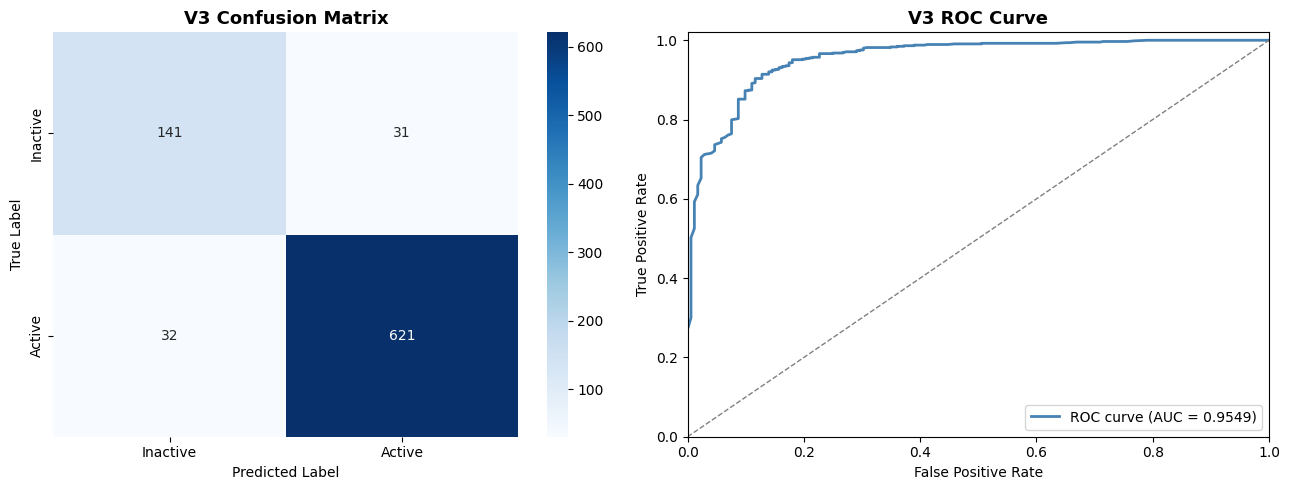

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Test Evaluation — auto-selects best available model (V3 > V2)
# ─────────────────────────────────────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, matthews_corrcoef, average_precision_score,
    precision_score, recall_score, confusion_matrix,
    precision_recall_curve, classification_report, roc_curve,
)

# ── Load best available model ─────────────────────────────────────────────────
_v3_path = 'models/best_finetuned_model_v3.pth'
_v2_path = 'models/best_finetuned_model_v2.pth'

if os.path.exists(_v3_path):
    _model_path  = _v3_path
    _model_label = 'V3'
    # Use V3 threshold from training session if available, else find from val set
    _default_thr = best_thr_v3 if 'best_thr_v3' in dir() else 0.5
    print(f"V3 threshold for test evaluation: {_default_thr:.3f}")
else:
    _model_path  = _v2_path
    _model_label = 'V2'
    #_default_thr = best_thr_v2 if 'best_thr_v2' in dir() else 0.61

print(f"Loading model: {_model_path}")
eval_model = torch.load(_model_path, weights_only=False, map_location=DEVICE)
eval_model.eval()

# ── Build datasets (self-contained) ──────────────────────────────────────────
print("Building evaluation datasets...")
if 'train_ds_v2' not in dir():
    train_ds_v2 = BioActivityDataset_v2(train_df, tokenizer, augment=False)
if 'val_ds_v2' not in dir():
    val_ds_v2 = BioActivityDataset_v2(val_df, tokenizer, scaler=train_ds_v2.scaler)
if 'test_ds_v2' not in dir():
    test_ds_v2 = BioActivityDataset_v2(test_df, tokenizer, scaler=train_ds_v2.scaler)

EVAL_BS = 64
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

# ── Inference helper ──────────────────────────────────────────────────────────
def get_probs(model, ds, batch_sz=EVAL_BS):
    probs, lbls = [], []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for i in range(0, len(ds), batch_sz):
            logits = model(
                input_ids      = ds.encodings['input_ids'][i:i+batch_sz].to(DEVICE),
                attention_mask = ds.encodings['attention_mask'][i:i+batch_sz].to(DEVICE),
                ecfp           = torch.tensor(ds.ecfp[i:i+batch_sz]).to(DEVICE),
                maccs          = torch.tensor(ds.maccs[i:i+batch_sz]).to(DEVICE),
                descriptors    = torch.tensor(ds.desc[i:i+batch_sz]).to(DEVICE),
            )
            probs.extend(torch.sigmoid(logits.float()).cpu().numpy())
            lbls.extend(ds.labels[i:i+batch_sz])
    return np.array(probs), np.array(lbls)

# ── Find optimal threshold on validation set ──────────────────────────────────
# print("Finding optimal threshold on validation set...")
# val_probs_e, val_labels_e = get_probs(eval_model, val_ds_v2)
# prec_e, rec_e, thr_e = precision_recall_curve(val_labels_e, val_probs_e)
# f1s_e    = 2 * prec_e * rec_e / (prec_e + rec_e + 1e-8)
# best_thr  = float(thr_e[np.argmax(f1s_e)])
# print(f"Optimal threshold (val F1-maximising): {best_thr:.3f}")

# ── Evaluate on test set ──────────────────────────────────────────────────────
print("\nEvaluating on test set...")
test_probs, test_labels = get_probs(eval_model, test_ds_v2)
test_preds = (test_probs > 0.599).astype(int)

tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()
metrics = {
    "Accuracy":     accuracy_score(test_labels, test_preds),
    "Balanced Acc": balanced_accuracy_score(test_labels, test_preds),
    "Precision":    precision_score(test_labels, test_preds, zero_division=0),
    "Recall":       recall_score(test_labels, test_preds, zero_division=0),
    "F1":           f1_score(test_labels, test_preds, zero_division=0),
    "ROC-AUC":      roc_auc_score(test_labels, test_probs),
    "AUPRC":        average_precision_score(test_labels, test_probs),
    "MCC":          matthews_corrcoef(test_labels, test_preds),
    "Sensitivity":  tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "Specificity":  tn / (tn + fp) if (tn + fp) > 0 else 0.0,
}

print("\n" + "=" * 58)
print(f"  {_model_label} Test-Set Evaluation — FineTunedBERTaECFP_{_model_label}")
print("=" * 58)
for k, v in metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=['Inactive', 'Active']))

# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
axes[0].set_title(f'{_model_label} Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{_model_label} ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# K-Fold Cross-Validation Training  (5 folds of V3 architecture)
#
# Why this helps: a single train/val split leaves 4/5 of the data unused
# for model selection. K-fold trains 5 models on different 80%/20% subsets
# of train+val, then ensemble their test predictions → lower variance,
# better generalisation, typically +1-2% AUC over a single model.
#
# Out-of-Fold (OOF) predictions:
#   Each molecule appears as the held-out 20% in exactly one fold.
#   The model for that fold was NEVER trained on it → unbiased predictions.
#   These OOF probabilities are used for threshold selection in the next cell.
#   This is the only statistically valid way to select a threshold when
#   val_df is included in the training pool.
# ─────────────────────────────────────────────────────────────────────────────
import os
from scipy import stats as _sci_stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef, precision_score, recall_score,
    confusion_matrix, cohen_kappa_score, brier_score_loss,
    precision_recall_curve,
)
from torch.utils.data import WeightedRandomSampler
from torch.optim.lr_scheduler import LambdaLR

N_FOLDS   = 5
KF_EPOCHS = 50    # max epochs per fold
KF_PAT    = 12     # early-stopping patience

_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

def _build_llrd_kf(model, base_lr, wd, decay=0.95):
    nd = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    g  = []
    hp = [(n, p) for n, p in model.named_parameters()
          if not n.startswith('bert.') and p.requires_grad]
    g += [
        {'params': [p for n, p in hp if not any(x in n for x in nd)], 'lr': base_lr, 'weight_decay': wd},
        {'params': [p for n, p in hp if     any(x in n for x in nd)], 'lr': base_lr, 'weight_decay': 0.0},
    ]
    for d, lyr in enumerate(reversed(list(model.bert.encoder.layer))):
        lr_l = base_lr * (decay ** d)
        lp   = [(n, p) for n, p in lyr.named_parameters() if p.requires_grad]
        if not lp:
            continue
        g += [
            {'params': [p for n, p in lp if not any(x in n for x in nd)], 'lr': lr_l, 'weight_decay': wd},
            {'params': [p for n, p in lp if     any(x in n for x in nd)], 'lr': lr_l, 'weight_decay': 0.0},
        ]
    if hasattr(model.bert, 'embeddings'):
        emb_lr = base_lr * (decay ** len(model.bert.encoder.layer))
        ep = [(n, p) for n, p in model.bert.embeddings.named_parameters() if p.requires_grad]
        if ep:
            g += [
                {'params': [p for n, p in ep if not any(x in n for x in nd)], 'lr': emb_lr, 'weight_decay': wd},
                {'params': [p for n, p in ep if     any(x in n for x in nd)], 'lr': emb_lr, 'weight_decay': 0.0},
            ]
    return optim.AdamW(g)

# ── Combine train + val (test stays held-out forever) ─────────────────────────
dev_df    = pd.concat([train_df, val_df], ignore_index=True)
dev_lbls  = dev_df['bioactivity'].values.astype(int)
print(f"Dev set : {len(dev_df):>5}  ({dev_lbls.sum()} Active, {(dev_lbls==0).sum()} Inactive)")
print(f"Test set: {len(test_df):>5}  (held out — never touched)")
print(f"Plan    : {N_FOLDS} folds × up to {KF_EPOCHS} epochs, collecting OOF predictions\n")

os.makedirs('models', exist_ok=True)

# OOF containers — filled fold by fold, indexed to dev_df positions
_oof_probs_full = np.zeros(len(dev_df), dtype=np.float32)
_oof_lbls_full  = dev_df['bioactivity'].values.astype(int)

skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_paths   = []
fold_scalers = []
fold_aucs    = []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(dev_df, dev_lbls)):
    print(f"\n{'='*58}")
    print(f"  FOLD {fold+1}/{N_FOLDS}  —  train {len(tr_idx)}  |  val(OOF) {len(vl_idx)}")
    print(f"{'='*58}")

    f_tr_df = dev_df.iloc[tr_idx].reset_index(drop=True)
    f_vl_df = dev_df.iloc[vl_idx].reset_index(drop=True)

    f_tr_ds = BioActivityDataset_v2(f_tr_df, tokenizer, augment=True)
    f_vl_ds = BioActivityDataset_v2(f_vl_df, tokenizer, scaler=f_tr_ds.scaler, augment=False)
    fold_scalers.append(f_tr_ds.scaler)

    _fl = f_tr_ds.labels.astype(int)
    _fw = (1.0 / np.bincount(_fl))[_fl]
    _fs = WeightedRandomSampler(torch.tensor(_fw, dtype=torch.float), len(_fw), replacement=True)

    f_tr_ldr = DataLoader(f_tr_ds, batch_size=best_params_v3['batch_size'],
                          sampler=_fs, collate_fn=collate_fn_v2, num_workers=0)
    f_vl_ldr = DataLoader(f_vl_ds, batch_size=best_params_v3['batch_size'] * 2,
                          shuffle=False, collate_fn=collate_fn_v2, num_workers=0)

    f_model = FineTunedBERTaECFP_v3(
        num_heads             = best_params_v3['num_heads'],
        dropout               = best_params_v3['dropout'],
        hidden_dim            = best_params_v3['hidden_dim'],
        num_classifier_layers = best_params_v3['num_classifier_layers'],
        n_cross_layers        = best_params_v3['n_cross_layers'],
        n_pool_layers         = 4,
        freeze_bottom_n       = FREEZE_BOTTOM_N,
    ).to(DEVICE)

    f_opt  = _build_llrd_kf(f_model, BASE_LR_V3, WD_V3, LLRD_FACTOR)
    f_crit = FocalLoss(alpha=0.50, gamma=2.0, smoothing=0.05)
    f_gscl = torch.cuda.amp.GradScaler(enabled=(USE_AMP and _AMP_DTYPE == torch.float16))

    _kf_total   = (len(f_tr_ldr) // GRAD_ACCUM_V3) * KF_EPOCHS
    _kf_warmup  = max(1, int(0.10 * _kf_total))
    def _kf_wc(step):
        if step < _kf_warmup:
            return float(step) / float(_kf_warmup)
        progress = float(step - _kf_warmup) / float(max(1, _kf_total - _kf_warmup))
        return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))
    f_sch = LambdaLR(f_opt, lr_lambda=_kf_wc)

    
    best_f_auc, f_pat = 0.0, 0
    f_save = f'models/kfold_v3_fold{fold+1}.pth'

    for epoch in range(KF_EPOCHS):
        f_model.train()
        f_opt.zero_grad()

        for bi, batch in enumerate(f_tr_ldr):
            eb = batch['ecfp'].to(DEVICE)
            mb = batch['maccs'].to(DEVICE)
            db = batch['descriptors'].to(DEVICE)
            lb = batch['labels'].float().to(DEVICE)

            with torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
                lg   = f_model(input_ids=batch['input_ids'].to(DEVICE),
                               attention_mask=batch['attention_mask'].to(DEVICE),
                               ecfp=eb, maccs=mb, descriptors=db)
                loss = f_crit(lg, lb) / GRAD_ACCUM_V3

            f_gscl.scale(loss).backward()
            if (bi + 1) % GRAD_ACCUM_V3 == 0:
                f_gscl.unscale_(f_opt)
                torch.nn.utils.clip_grad_norm_(f_model.parameters(), 1.0)
                f_gscl.step(f_opt); f_gscl.update(); f_opt.zero_grad(); f_sch.step()

        f_model.eval()
        vp_l, vl_l = [], []
        with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
            for vb in f_vl_ldr:
                vl = f_model(input_ids=vb['input_ids'].to(DEVICE),
                             attention_mask=vb['attention_mask'].to(DEVICE),
                             ecfp=vb['ecfp'].to(DEVICE),
                             maccs=vb['maccs'].to(DEVICE),
                             descriptors=vb['descriptors'].to(DEVICE))
                vp_l.extend(torch.sigmoid(vl.float()).cpu().numpy())
                vl_l.extend(vb['labels'].cpu().numpy())

        f_auc = roc_auc_score(vl_l, vp_l)
        print(f"  Ep {epoch+1:02d}/{KF_EPOCHS} | AUC={f_auc:.4f}", end='\r')

        if f_auc > best_f_auc:
            best_f_auc = f_auc; f_pat = 0
            torch.save(f_model, f_save)
        else:
            f_pat += 1
            if f_pat >= KF_PAT:
                print(f"\n  Early stop at epoch {epoch+1}"); break

    print(f"\n  Fold {fold+1} Best AUC: {best_f_auc:.4f}  →  {f_save}")

    # ── Collect OOF predictions (best model, no training on vl_idx) ───────────
    del f_model; torch.cuda.empty_cache()

    _best_fm = torch.load(f_save, weights_only=False, map_location=DEVICE)
    _best_fm.eval()
    _oof_p = []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for _i in range(0, len(f_vl_ds), 64):
            _lg = _best_fm(
                input_ids      = f_vl_ds.encodings['input_ids'][_i:_i+64].to(DEVICE),
                attention_mask = f_vl_ds.encodings['attention_mask'][_i:_i+64].to(DEVICE),
                ecfp           = torch.tensor(f_vl_ds.ecfp[_i:_i+64]).to(DEVICE),
                maccs          = torch.tensor(f_vl_ds.maccs[_i:_i+64]).to(DEVICE),
                descriptors    = torch.tensor(f_vl_ds.desc[_i:_i+64]).to(DEVICE),
            )
            _oof_p.extend(torch.sigmoid(_lg.float()).cpu().numpy())

    _oof_probs_full[vl_idx] = np.array(_oof_p, dtype=np.float32)
    del _best_fm; torch.cuda.empty_cache()

    fold_paths.append(f_save)
    fold_aucs.append(best_f_auc)

print(f"\n{'='*58}")
print(f"K-Fold complete")
print(f"Mean AUC (val)  : {np.mean(fold_aucs):.4f}  ±  {np.std(fold_aucs):.4f}")
print(f"Per-fold        : {[f'{a:.4f}' for a in fold_aucs]}")
print(f"OOF AUC (dev)   : {roc_auc_score(_oof_lbls_full, _oof_probs_full):.4f}  ← unbiased estimate")

# ─────────────────────────────────────────────────────────────────────────────
# K-Fold OOF — Comprehensive Metrics Table
#
# Re-derives the same fold splits (same seed) to slice _oof_probs_full into
# per-fold held-out chunks, computes 13 metrics per fold, then reports
# mean ± std, min, max, and 95% CI (t-distribution, df=N_FOLDS-1).
# ─────────────────────────────────────────────────────────────────────────────

# ── OOF-optimal threshold (maximise F1 on the full OOF set) ──────────────────
_p_oof, _r_oof, _thr_oof = precision_recall_curve(_oof_lbls_full, _oof_probs_full)
_f1s_oof = 2 * _p_oof * _r_oof / np.where((_p_oof + _r_oof) == 0, 1, _p_oof + _r_oof)
_cv_thr  = float(_thr_oof[np.argmax(_f1s_oof[:-1])])
print(f"\nOOF optimal threshold (max-F1): {_cv_thr:.4f}")

# ── Per-fold metric helper ────────────────────────────────────────────────────
def _compute_fold_metrics(probs, labels, thr):
    preds          = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    spec           = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv_           = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {
        'Accuracy'    : accuracy_score(labels, preds),
        'Balanced Acc': balanced_accuracy_score(labels, preds),
        'Precision'   : precision_score(labels, preds, zero_division=0),
        'Recall'      : recall_score(labels, preds, zero_division=0),
        'F1'          : f1_score(labels, preds, zero_division=0),
        'ROC-AUC'     : roc_auc_score(labels, probs),
        'AUPRC'       : average_precision_score(labels, probs),
        'MCC'         : matthews_corrcoef(labels, preds),
        'Sensitivity' : recall_score(labels, preds, zero_division=0),
        'Specificity' : spec,
        'NPV'         : npv_,
        'Cohen s k'   : cohen_kappa_score(labels, preds),
        'Brier'       : brier_score_loss(labels, probs),
    }

# Re-derive fold splits with the same seed → same splits as training
_skf_eval  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
_fold_stats = []
for _, vl_idx in _skf_eval.split(dev_df, dev_lbls):
    _fold_stats.append(
        _compute_fold_metrics(
            _oof_probs_full[vl_idx],
            _oof_lbls_full[vl_idx],
            _cv_thr,
        )
    )

# ── Aggregate ─────────────────────────────────────────────────────────────────
_metric_keys = list(_fold_stats[0].keys())
_agg = {}
for m in _metric_keys:
    vals  = np.array([f[m] for f in _fold_stats])
    mean  = vals.mean()
    std   = vals.std(ddof=1)
    ci_hw = _sci_stats.t.ppf(0.975, df=N_FOLDS - 1) * std / np.sqrt(N_FOLDS)
    _agg[m] = dict(mean=mean, std=std, min=vals.min(), max=vals.max(),
                   ci_lo=mean - ci_hw, ci_hi=mean + ci_hw)

# ── Full table ────────────────────────────────────────────────────────────────
print("\n" + "=" * 74)
print(f"{'Metric':<14}  {'Mean ± Std':>18}  {'Min':>7}  {'Max':>7}  {'95% CI':>20}")
print("=" * 74)
for m, s in _agg.items():
    print(f"{m:<14}  {s['mean']:.4f} +- {s['std']:.4f}  "
          f"{s['min']:.4f}  {s['max']:.4f}  "
          f"[{s['ci_lo']:.4f}, {s['ci_hi']:.4f}]")
print("=" * 74)

# ── Paper-ready summary ───────────────────────────────────────────────────────
_paper_keys = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
               'Sensitivity', 'Specificity', 'Cohen s k', 'Brier']
print(f"\n  Paper-Ready Summary\n")
print(f"{'':>16}{'Model ('+str(N_FOLDS)+'-Fold CV)'}")
for m in _paper_keys:
    s = _agg[m]
    print(f"{m:<16}  {s['mean']:.4f} +- {s['std']:.4f}")


Dev set :  4669  (3673 Active, 996 Inactive)
Test set:   825  (held out — never touched)
Plan    : 5 folds × up to 50 epochs, collecting OOF predictions


  FOLD 1/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 29/50 | AUC=0.9472
  Early stop at epoch 29

  Fold 1 Best AUC: 0.9480  →  models/kfold_v3_fold1.pth

  FOLD 2/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 32/50 | AUC=0.9601
  Early stop at epoch 32

  Fold 2 Best AUC: 0.9625  →  models/kfold_v3_fold2.pth

  FOLD 3/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 35/50 | AUC=0.9575
  Early stop at epoch 35

  Fold 3 Best AUC: 0.9579  →  models/kfold_v3_fold3.pth

  FOLD 4/5  —  train 3735  |  val(OOF) 934
Computing ECFP...
Computing MACCS...
Computing ECFP...
Computing MACCS...
  Ep 39/50 | AUC=0.9643
  Early stop at epoch 39

  Fold

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# K-Fold Ensemble — Test Inference & Evaluation  (no TTA)
#
# Threshold selection uses Out-of-Fold (OOF) predictions — NOT val_df.
# Each fold model does a single forward pass on the original test SMILES.
# Final probability = mean across all N_FOLDS models.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, matthews_corrcoef, average_precision_score,
    precision_score, recall_score, confusion_matrix, classification_report,
)

def _batch_infer(model, ds, batch_sz=64):
    model.eval()
    probs = []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for i in range(0, len(ds), batch_sz):
            lg = model(
                input_ids      = ds.encodings['input_ids'][i:i+batch_sz].to(DEVICE),
                attention_mask = ds.encodings['attention_mask'][i:i+batch_sz].to(DEVICE),
                ecfp           = torch.tensor(ds.ecfp[i:i+batch_sz]).to(DEVICE),
                maccs          = torch.tensor(ds.maccs[i:i+batch_sz]).to(DEVICE),
                descriptors    = torch.tensor(ds.desc[i:i+batch_sz]).to(DEVICE),
            )
            probs.extend(torch.sigmoid(lg.float()).cpu().numpy())
    return np.array(probs)

# ── OOF threshold selection (unbiased) ───────────────────────────────────────
print("Selecting threshold from OOF predictions (unbiased)...")
_thrs   = np.linspace(0.10, 0.90, 500)  # fine-grained search for best balanced accuracy
_ba_oof = np.array([
    matthews_corrcoef(_oof_lbls_full, (_oof_probs_full > t).astype(int))
    for t in _thrs
])
kf_thr  = float(_thrs[np.argmax(_ba_oof)])
oof_auc = roc_auc_score(_oof_lbls_full, _oof_probs_full)
print(f"  OOF AUC             : {oof_auc:.4f}")
print(f"  OOF best MCC        : {_ba_oof.max():.4f}  at threshold {kf_thr:.3f}")

# ── Build test dataset (single canonical SMILES per molecule) ─────────────────
_ref_scaler  = fold_scalers[-1]   # fit on ~80% of same data — consistent across folds
test_ds_eval = BioActivityDataset_v2(test_df, tokenizer, scaler=_ref_scaler, augment=False)
print(f"\nTest set: {len(test_ds_eval)} molecules")

# ── Accumulate predictions from all fold models ───────────────────────────────
kf_test_sum = np.zeros(len(test_df))

for i, fpath in enumerate(fold_paths):
    print(f"Fold {i+1}/{N_FOLDS}: {fpath} ...", end='  ')
    fm = torch.load(fpath, weights_only=False, map_location=DEVICE)
    kf_test_sum += _batch_infer(fm, test_ds_eval)
    del fm; torch.cuda.empty_cache()
    print("done.")

kf_test_probs = kf_test_sum / N_FOLDS
kf_test_lbls  = test_df['bioactivity'].values

# ── Final test evaluation ─────────────────────────────────────────────────────
kf_preds           = (kf_test_probs > kf_thr).astype(int)
tn_, fp_, fn_, tp_ = confusion_matrix(kf_test_lbls, kf_preds).ravel()

kf_res = {
    'Accuracy'    : accuracy_score(kf_test_lbls, kf_preds),
    'Balanced Acc': balanced_accuracy_score(kf_test_lbls, kf_preds),
    'Precision'   : precision_score(kf_test_lbls, kf_preds, zero_division=0),
    'Recall'      : recall_score(kf_test_lbls, kf_preds, zero_division=0),
    'F1'          : f1_score(kf_test_lbls, kf_preds, zero_division=0),
    'ROC-AUC'     : roc_auc_score(kf_test_lbls, kf_test_probs),
    'AUPRC'       : average_precision_score(kf_test_lbls, kf_test_probs),
    'MCC'         : matthews_corrcoef(kf_test_lbls, kf_preds),
    'Sensitivity' : tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0,
    'Specificity' : tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0.0,
}

print("\n" + "=" * 60)
print(f"  K-Fold ({N_FOLDS}) Ensemble — V3 Architecture (no TTA)")
print(f"  Threshold : {kf_thr:.3f}  (OOF MCC optimal)")
print("=" * 60)
for k, v in kf_res.items():
    print(f"  {k:<22}: {v:.4f}")
print()
print(classification_report(kf_test_lbls, kf_preds, target_names=['Inactive', 'Active']))


Selecting threshold from OOF predictions (unbiased)...
  OOF AUC             : 0.9584
  OOF best MCC        : 0.7899  at threshold 0.483
Computing ECFP...
Computing MACCS...

Test set: 825 molecules
Fold 1/5: models/kfold_v3_fold1.pth ...  done.
Fold 2/5: models/kfold_v3_fold2.pth ...  done.
Fold 3/5: models/kfold_v3_fold3.pth ...  done.
Fold 4/5: models/kfold_v3_fold4.pth ...  done.
Fold 5/5: models/kfold_v3_fold5.pth ...  done.

  K-Fold (5) Ensemble — V3 Architecture (no TTA)
  Threshold : 0.483  (OOF MCC optimal)
  Accuracy              : 0.9236
  Balanced Acc          : 0.8832
  Precision             : 0.9511
  Recall                : 0.9525
  F1                    : 0.9518
  ROC-AUC               : 0.9633
  AUPRC                 : 0.9890
  MCC                   : 0.7681
  Sensitivity           : 0.9525
  Specificity           : 0.8140

              precision    recall  f1-score   support

    Inactive       0.82      0.81      0.82       172
      Active       0.95      0.95    

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# V3 Training — uses best_params_v3 from V3 HPO above
#
# WeightedRandomSampler + LLRD + linear warmup/cosine decay
# focal_alpha=0.50 (neutral): sampler handles class balance; gamma handles hard examples
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import balanced_accuracy_score
from torch.optim.lr_scheduler import LambdaLR

# ── Load best V3 params from HPO ──────────────────────────────────────────────
best_params_v3 = dict(best_params_v3)
best_params_v3['focal_alpha'] = 0.50   # fixed (not searched — sampler handles balance)

# Manual fallback if HPO hasn't been run:
# best_params_v3 = {
#     'num_heads': 8, 'hidden_dim': 512, 'dropout': 0.2,
#     'num_classifier_layers': 3, 'n_cross_layers': 3,
#     'batch_size': 32, 'learning_rate': 5e-6, 'weight_decay': 1e-4,
#     'focal_alpha': 0.50,
# }

GRAD_ACCUM_V3   = 2
EPOCHS_V3       = 60
PATIENCE_V3     = 12
LLRD_FACTOR     = 0.95
FREEZE_BOTTOM_N = 4

BASE_LR_V3 = best_params_v3['learning_rate']
WD_V3      = best_params_v3['weight_decay']

USE_AMP    = DEVICE.type == 'cuda'
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

print("Best V3 params:", best_params_v3)
print("\nBuilding V3 datasets...")
if 'train_ds_v2' not in dir():
    train_ds_v2 = BioActivityDataset_v2(train_df, tokenizer, augment=True)
if 'val_ds_v2' not in dir():
    val_ds_v2 = BioActivityDataset_v2(val_df, tokenizer, scaler=train_ds_v2.scaler)
if 'test_ds_v2' not in dir():
    test_ds_v2 = BioActivityDataset_v2(test_df, tokenizer, scaler=train_ds_v2.scaler)

BS_V3 = best_params_v3['batch_size']

# ── WeightedRandomSampler ─────────────────────────────────────────────────────
_labels      = train_ds_v2.labels.astype(int)
_class_count = np.bincount(_labels)
_class_wt    = 1.0 / _class_count
_sample_wt   = _class_wt[_labels]
_sampler = WeightedRandomSampler(
    weights=torch.tensor(_sample_wt, dtype=torch.float),
    num_samples=len(_sample_wt), replacement=True,
)
train_loader_v3 = DataLoader(train_ds_v2, batch_size=BS_V3, sampler=_sampler,
                             collate_fn=collate_fn_v2, num_workers=0, pin_memory=True)
val_loader_v3   = DataLoader(val_ds_v2,   batch_size=BS_V3 * 2, shuffle=False,
                             collate_fn=collate_fn_v2, num_workers=0, pin_memory=True)
print(f"Class counts — Inactive: {_class_count[0]}, Active: {_class_count[1]}")

# ── Build V3 model ────────────────────────────────────────────────────────────
model_v3 = FineTunedBERTaECFP_v3(
    num_heads             = best_params_v3['num_heads'],
    dropout               = best_params_v3['dropout'],
    hidden_dim            = best_params_v3['hidden_dim'],
    num_classifier_layers = best_params_v3['num_classifier_layers'],
    n_cross_layers        = best_params_v3['n_cross_layers'],   # from HPO
    n_pool_layers         = 4,
    freeze_bottom_n       = FREEZE_BOTTOM_N,   # handled in __init__
).to(DEVICE)
print(f"Froze bottom {FREEZE_BOTTOM_N} BERT layers via __init__. Top {12-FREEZE_BOTTOM_N} trainable via LLRD.")

# ── FocalLoss — alpha=0.5 (neutral), gamma=2.0 focuses on hard examples ──────
criterion_v3 = FocalLoss(alpha=0.50, gamma=2.0, smoothing=0.05)

# ── LLRD Optimizer ────────────────────────────────────────────────────────────
def build_llrd_optimizer(model, base_lr, weight_decay, decay_factor=0.95):
    no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    n_layers = len(model.bert.encoder.layer)
    groups   = []

    head_params = [(n, p) for n, p in model.named_parameters()
                   if not n.startswith('bert.') and p.requires_grad]
    groups += [
        {'params': [p for n, p in head_params if not any(nd in n for nd in no_decay)],
         'lr': base_lr, 'weight_decay': weight_decay},
        {'params': [p for n, p in head_params if any(nd in n for nd in no_decay)],
         'lr': base_lr, 'weight_decay': 0.0},
    ]

    for depth, layer in enumerate(reversed(list(model.bert.encoder.layer))):
        lr_l = base_lr * (decay_factor ** depth)
        lp   = [(n, p) for n, p in layer.named_parameters() if p.requires_grad]
        if not lp:
            continue
        groups += [
            {'params': [p for n, p in lp if not any(nd in n for nd in no_decay)],
             'lr': lr_l, 'weight_decay': weight_decay},
            {'params': [p for n, p in lp if any(nd in n for nd in no_decay)],
             'lr': lr_l, 'weight_decay': 0.0},
        ]

    if hasattr(model.bert, 'embeddings'):
        emb_lr = base_lr * (decay_factor ** n_layers)
        ep     = [(n, p) for n, p in model.bert.embeddings.named_parameters()
                  if p.requires_grad]
        if ep:
            groups += [
                {'params': [p for n, p in ep if not any(nd in n for nd in no_decay)],
                 'lr': emb_lr, 'weight_decay': weight_decay},
                {'params': [p for n, p in ep if any(nd in n for nd in no_decay)],
                 'lr': emb_lr, 'weight_decay': 0.0},
            ]
    return optim.AdamW(groups)

optimizer_v3 = build_llrd_optimizer(model_v3, BASE_LR_V3, WD_V3, LLRD_FACTOR)

# ── Linear warmup + cosine decay ─────────────────────────────────────────────
total_steps_v3  = (len(train_loader_v3) // GRAD_ACCUM_V3) * EPOCHS_V3
warmup_steps_v3 = int(0.10 * total_steps_v3)

def warmup_cosine_lambda(step):
    if step < warmup_steps_v3:
        return float(step) / float(max(1, warmup_steps_v3))
    progress = float(step - warmup_steps_v3) / float(max(1, total_steps_v3 - warmup_steps_v3))
    return max(1e-7, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler_v3  = LambdaLR(optimizer_v3, lr_lambda=warmup_cosine_lambda)
amp_scaler_v3 = torch.cuda.amp.GradScaler(enabled=(USE_AMP and _AMP_DTYPE == torch.float16))

print(f"\nV3 | LLRD ξ={LLRD_FACTOR} | Base LR: {BASE_LR_V3:.2e} | WD: {WD_V3:.2e}")
print(f"Focal α=0.50 (neutral) γ=2.0 | Batch: {BS_V3} | Epochs: {EPOCHS_V3} | Patience: {PATIENCE_V3}")
print(f"Warmup: {warmup_steps_v3} steps | Total: {total_steps_v3} | Grad accum: {GRAD_ACCUM_V3}")
print("=" * 70)

# ── Training loop ─────────────────────────────────────────────────────────────
best_auc_v3, patience_ctr_v3, best_thr_v3 = 0.0, 0, 0.5
global_step_v3 = 0

for epoch in range(EPOCHS_V3):
    model_v3.train()
    running_loss = 0.0
    optimizer_v3.zero_grad()

    for batch_idx, batch in enumerate(train_loader_v3):
        ecfp_b  = batch['ecfp'].to(DEVICE)
        maccs_b = batch['maccs'].to(DEVICE)
        desc_b  = batch['descriptors'].to(DEVICE)
        lbl_b   = batch['labels'].float().to(DEVICE)

        with torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
            logits = model_v3(
                input_ids      = batch['input_ids'].to(DEVICE),
                attention_mask = batch['attention_mask'].to(DEVICE),
                ecfp=ecfp_b, maccs=maccs_b, descriptors=desc_b,
            )
            loss = criterion_v3(logits, lbl_b) / GRAD_ACCUM_V3

        amp_scaler_v3.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM_V3

        if (batch_idx + 1) % GRAD_ACCUM_V3 == 0:
            amp_scaler_v3.unscale_(optimizer_v3)
            torch.nn.utils.clip_grad_norm_(model_v3.parameters(), max_norm=1.0)
            amp_scaler_v3.step(optimizer_v3)
            amp_scaler_v3.update()
            optimizer_v3.zero_grad()
            scheduler_v3.step()
            global_step_v3 += 1

    # ── Validation ────────────────────────────────────────────────────────────
    model_v3.eval()
    val_probs_v3, val_lbls_v3 = [], []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for vbatch in val_loader_v3:
            vlogits = model_v3(
                input_ids      = vbatch['input_ids'].to(DEVICE),
                attention_mask = vbatch['attention_mask'].to(DEVICE),
                ecfp           = vbatch['ecfp'].to(DEVICE),
                maccs          = vbatch['maccs'].to(DEVICE),
                descriptors    = vbatch['descriptors'].to(DEVICE),
            )
            val_probs_v3.extend(torch.sigmoid(vlogits.float()).cpu().numpy())
            val_lbls_v3.extend(vbatch['labels'].cpu().numpy())

    val_probs_v3 = np.array(val_probs_v3)
    val_lbls_v3  = np.array(val_lbls_v3)
    val_auc_v3   = roc_auc_score(val_lbls_v3, val_probs_v3)

    prec_v, rec_v, thr_v = precision_recall_curve(val_lbls_v3, val_probs_v3)
    f1s_v   = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
    opt_thr = float(thr_v[np.argmax(f1s_v)])
    preds_v = (val_probs_v3 > opt_thr).astype(int)

    acc_v     = accuracy_score(val_lbls_v3, preds_v)
    bal_acc_v = balanced_accuracy_score(val_lbls_v3, preds_v)
    f1_v      = f1_score(val_lbls_v3, preds_v, zero_division=0)

    print(f'Epoch {epoch+1:02d}/{EPOCHS_V3} | '
          f'Loss {running_loss/len(train_loader_v3):.4f} | '
          f'AUROC {val_auc_v3:.4f} | Acc {acc_v:.4f} | '
          f'BalAcc {bal_acc_v:.4f} | F1 {f1_v:.4f} | Thr {opt_thr:.3f}')

    if val_auc_v3 > best_auc_v3:
        best_auc_v3     = val_auc_v3
        best_thr_v3     = opt_thr
        patience_ctr_v3 = 0
        torch.save(model_v3, 'models/best_finetuned_model_v3.pth')
        print(f'  ✓ New best — saved to models/best_finetuned_model_v3.pth')
    else:
        patience_ctr_v3 += 1
        if patience_ctr_v3 >= PATIENCE_V3:
            print(f'Early stopping at epoch {epoch+1}.')
            break

print(f'\nBest Val AUROC: {best_auc_v3:.4f} | Optimal Threshold: {best_thr_v3:.3f}')
print('Saved: models/best_finetuned_model_v3.pth')


Best V3 params: {'num_heads': 4, 'hidden_dim': 256, 'dropout': 0.1, 'num_classifier_layers': 2, 'n_cross_layers': 2, 'batch_size': 32, 'learning_rate': 9.8916998354799e-06, 'weight_decay': 2.1247834038360546e-05, 'focal_alpha': 0.5}

Building V3 datasets...
Class counts — Inactive: 817, Active: 3028
Froze bottom 4 BERT layers via __init__. Top 8 trainable via LLRD.

V3 | LLRD ξ=0.95 | Base LR: 9.89e-06 | WD: 2.12e-05
Focal α=0.50 (neutral) γ=2.0 | Batch: 32 | Epochs: 60 | Patience: 12
Warmup: 360 steps | Total: 3600 | Grad accum: 2
Epoch 01/60 | Loss 0.0872 | AUROC 0.6836 | Acc 0.8058 | BalAcc 0.5652 | F1 0.8887 | Thr 0.356
  ✓ New best — saved to models/best_finetuned_model_v3.pth
Epoch 02/60 | Loss 0.0739 | AUROC 0.8241 | Acc 0.8265 | BalAcc 0.6328 | F1 0.8979 | Thr 0.373
  ✓ New best — saved to models/best_finetuned_model_v3.pth
Epoch 03/60 | Loss 0.0619 | AUROC 0.8737 | Acc 0.8459 | BalAcc 0.6796 | F1 0.9082 | Thr 0.324
  ✓ New best — saved to models/best_finetuned_model_v3.pth
Epo

Loading model: models/best_finetuned_model_v3.pth
Building evaluation datasets...

Evaluating on test set...

  V3 Test-Set Evaluation — FineTunedBERTaECFP_V3
  Accuracy            : 0.9103
  Balanced Acc        : 0.8363
  Precision           : 0.9264
  Recall              : 0.9632
  F1                  : 0.9444
  ROC-AUC             : 0.9533
  AUPRC               : 0.9856
  MCC                 : 0.7159
  Sensitivity         : 0.9632
  Specificity         : 0.7093

              precision    recall  f1-score   support

    Inactive       0.84      0.71      0.77       172
      Active       0.93      0.96      0.94       653

    accuracy                           0.91       825
   macro avg       0.88      0.84      0.86       825
weighted avg       0.91      0.91      0.91       825



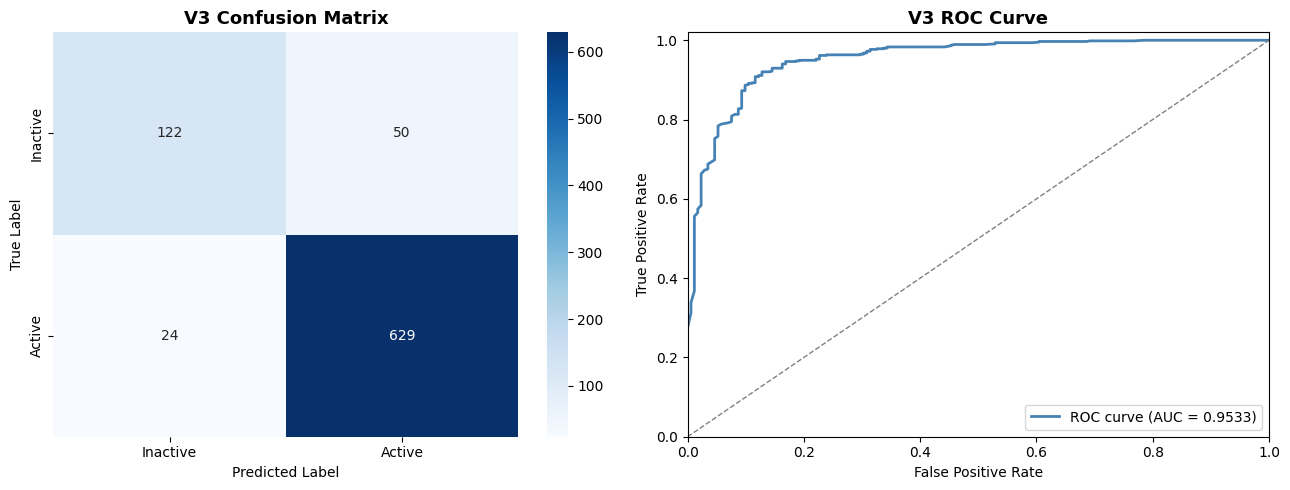

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# Test Evaluation — auto-selects best available model (V3 > V2)
# ─────────────────────────────────────────────────────────────────────────────
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, matthews_corrcoef, average_precision_score,
    precision_score, recall_score, confusion_matrix,
    precision_recall_curve, classification_report, roc_curve,
)

# ── Load best available model ─────────────────────────────────────────────────
_v3_path = 'models/best_finetuned_model_v3.pth'
_v2_path = 'models/best_finetuned_model_v2.pth'

if os.path.exists(_v3_path):
    _model_path  = _v3_path
    _model_label = 'V3'
    # Use V3 threshold from training session if available, else find from val set
    _default_thr = best_thr_v3 if 'best_thr_v3' in dir() else 0.5
else:
    _model_path  = _v2_path
    _model_label = 'V2'
    _default_thr = best_thr_v2 if 'best_thr_v2' in dir() else 0.61

print(f"Loading model: {_model_path}")
eval_model = torch.load(_model_path, weights_only=False, map_location=DEVICE)
eval_model.eval()

# ── Build datasets (self-contained) ──────────────────────────────────────────
print("Building evaluation datasets...")
if 'train_ds_v2' not in dir():
    train_ds_v2 = BioActivityDataset_v2(train_df, tokenizer, augment=False)
if 'val_ds_v2' not in dir():
    val_ds_v2 = BioActivityDataset_v2(val_df, tokenizer, scaler=train_ds_v2.scaler)
if 'test_ds_v2' not in dir():
    test_ds_v2 = BioActivityDataset_v2(test_df, tokenizer, scaler=train_ds_v2.scaler)

EVAL_BS = 64
_DEV_TYPE  = DEVICE.type
_AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16

# ── Inference helper ──────────────────────────────────────────────────────────
def get_probs(model, ds, batch_sz=EVAL_BS):
    probs, lbls = [], []
    with torch.no_grad(), torch.amp.autocast(device_type=_DEV_TYPE, dtype=_AMP_DTYPE, enabled=USE_AMP):
        for i in range(0, len(ds), batch_sz):
            logits = model(
                input_ids      = ds.encodings['input_ids'][i:i+batch_sz].to(DEVICE),
                attention_mask = ds.encodings['attention_mask'][i:i+batch_sz].to(DEVICE),
                ecfp           = torch.tensor(ds.ecfp[i:i+batch_sz]).to(DEVICE),
                maccs          = torch.tensor(ds.maccs[i:i+batch_sz]).to(DEVICE),
                descriptors    = torch.tensor(ds.desc[i:i+batch_sz]).to(DEVICE),
            )
            probs.extend(torch.sigmoid(logits.float()).cpu().numpy())
            lbls.extend(ds.labels[i:i+batch_sz])
    return np.array(probs), np.array(lbls)

# ── Find optimal threshold on validation set ──────────────────────────────────
# print("Finding optimal threshold on validation set...")
# val_probs_e, val_labels_e = get_probs(eval_model, val_ds_v2)
# prec_e, rec_e, thr_e = precision_recall_curve(val_labels_e, val_probs_e)
# f1s_e    = 2 * prec_e * rec_e / (prec_e + rec_e + 1e-8)
# best_thr  = float(thr_e[np.argmax(f1s_e)])
# print(f"Optimal threshold (val F1-maximising): {best_thr:.3f}")

# ── Evaluate on test set ──────────────────────────────────────────────────────
print("\nEvaluating on test set...")
test_probs, test_labels = get_probs(eval_model, test_ds_v2)
test_preds = (test_probs > 0.302).astype(int)

tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel()
metrics = {
    "Accuracy":     accuracy_score(test_labels, test_preds),
    "Balanced Acc": balanced_accuracy_score(test_labels, test_preds),
    "Precision":    precision_score(test_labels, test_preds, zero_division=0),
    "Recall":       recall_score(test_labels, test_preds, zero_division=0),
    "F1":           f1_score(test_labels, test_preds, zero_division=0),
    "ROC-AUC":      roc_auc_score(test_labels, test_probs),
    "AUPRC":        average_precision_score(test_labels, test_probs),
    "MCC":          matthews_corrcoef(test_labels, test_preds),
    "Sensitivity":  tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "Specificity":  tn / (tn + fp) if (tn + fp) > 0 else 0.0,
}

print("\n" + "=" * 58)
print(f"  {_model_label} Test-Set Evaluation — FineTunedBERTaECFP_{_model_label}")
print("=" * 58)
for k, v in metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=['Inactive', 'Active']))

# ── Confusion Matrix + ROC Curve ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
axes[0].set_title(f'{_model_label} Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{_model_label} ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()